In [1]:
import os
os.system('pip install scikit-learn pandas numpy matplotlib seaborn -q')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [5]:
# Step 1: Upload the file from your PC
from google.colab import files
uploaded = files.upload()  # A button will appear — click it and select archive (5).zip

Saving archive (5).zip to archive (5).zip


In [6]:
import zipfile
import pandas as pd

# Step 2: Extract and load
with zipfile.ZipFile('archive (5).zip', 'r') as z:
    print(z.namelist())
    with z.open('german_credit_data.csv') as f:
        df = pd.read_csv(f)

print(df.shape)
print(df.head())
print(df.columns.tolist())

['german_credit_data.csv']
(1000, 21)
   laufkont  laufzeit  moral  verw  hoehe  sparkont  beszeit  rate  famges  \
0         1        18      4     2   1049         1        2     4       2   
1         1         9      4     0   2799         1        3     2       3   
2         2        12      2     9    841         2        4     2       2   
3         1        12      4     0   2122         1        3     3       3   
4         1        12      4     0   2171         1        3     4       3   

   buerge  ...  verm  alter  weitkred  wohn  bishkred  beruf  pers  telef  \
0       1  ...     2     21         3     1         1      3     2      1   
1       1  ...     1     36         3     1         2      3     1      1   
2       1  ...     1     23         3     1         1      2     2      1   
3       1  ...     1     39         3     1         2      2     1      1   
4       1  ...     2     38         1     2         2      2     2      1   

   gastarb  kredit  
0        

In [7]:
# Check missing values
print(df.isnull().sum())

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Fill any remaining nulls
df.fillna(df.median(numeric_only=True), inplace=True)

print("Cleaned! Shape:", df.shape)

laufkont    0
laufzeit    0
moral       0
verw        0
hoehe       0
sparkont    0
beszeit     0
rate        0
famges      0
buerge      0
wohnzeit    0
verm        0
alter       0
weitkred    0
wohn        0
bishkred    0
beruf       0
pers        0
telef       0
gastarb     0
kredit      0
dtype: int64
Cleaned! Shape: (1000, 21)


In [9]:
print(df.columns.tolist())
print(df.head(2))


['laufkont', 'laufzeit', 'moral', 'verw', 'hoehe', 'sparkont', 'beszeit', 'rate', 'famges', 'buerge', 'wohnzeit', 'verm', 'alter', 'weitkred', 'wohn', 'bishkred', 'beruf', 'pers', 'telef', 'gastarb', 'kredit']
   laufkont  laufzeit  moral  verw  hoehe  sparkont  beszeit  rate  famges  \
0         1        18      4     2   1049         1        2     4       2   
1         1         9      4     0   2799         1        3     2       3   

   buerge  ...  verm  alter  weitkred  wohn  bishkred  beruf  pers  telef  \
0       1  ...     2     21         3     1         1      3     2      1   
1       1  ...     1     36         3     1         2      3     1      1   

   gastarb  kredit  
0        2       1  
1        2       1  

[2 rows x 21 columns]


In [10]:
# Target is 'kredit', features are everything else
X = df.drop('kredit', axis=1)
y = df['kredit']

# New feature
X = X.copy()
X['duration_amount_ratio'] = X['laufzeit'] / (X['hoehe'] + 1)

# Encode categoricals
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col].astype(str))

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (800, 21) Test: (200, 21)


In [11]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("All models trained!")

All models trained!


In [12]:
models = {'Logistic Regression': lr, 'Decision Tree': dt, 'Random Forest': rf}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")


Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.66      0.55      0.60        60
           1       0.82      0.88      0.85       140

    accuracy                           0.78       200
   macro avg       0.74      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200

ROC-AUC: 0.8195

Model: Decision Tree
              precision    recall  f1-score   support

           0       0.61      0.55      0.58        60
           1       0.82      0.85      0.83       140

    accuracy                           0.76       200
   macro avg       0.71      0.70      0.71       200
weighted avg       0.75      0.76      0.76       200

ROC-AUC: 0.7595

Model: Random Forest
              precision    recall  f1-score   support

           0       0.72      0.52      0.60        60
           1       0.82      0.91      0.86       140

    accuracy                           0.80       200
   macro avg       0.77 

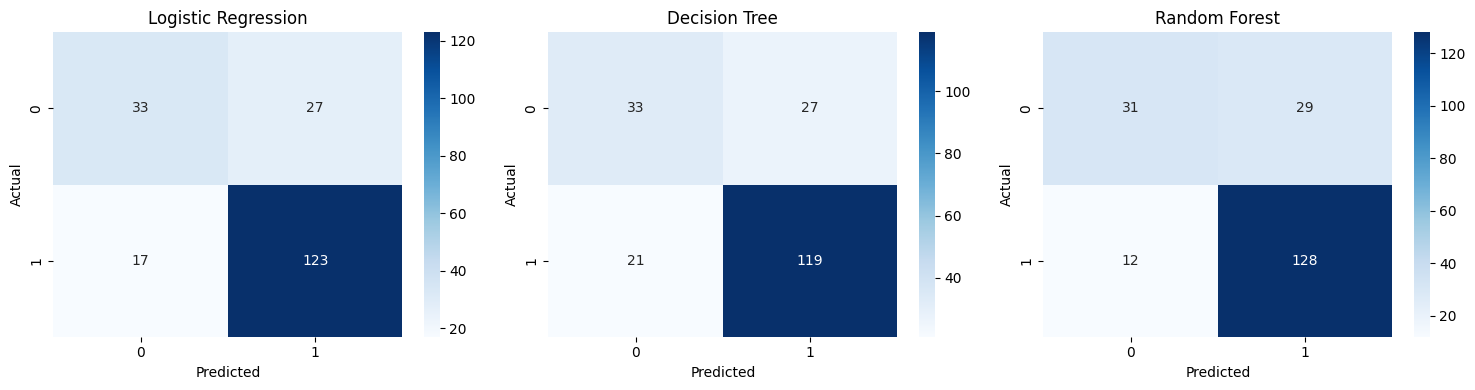

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues')
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

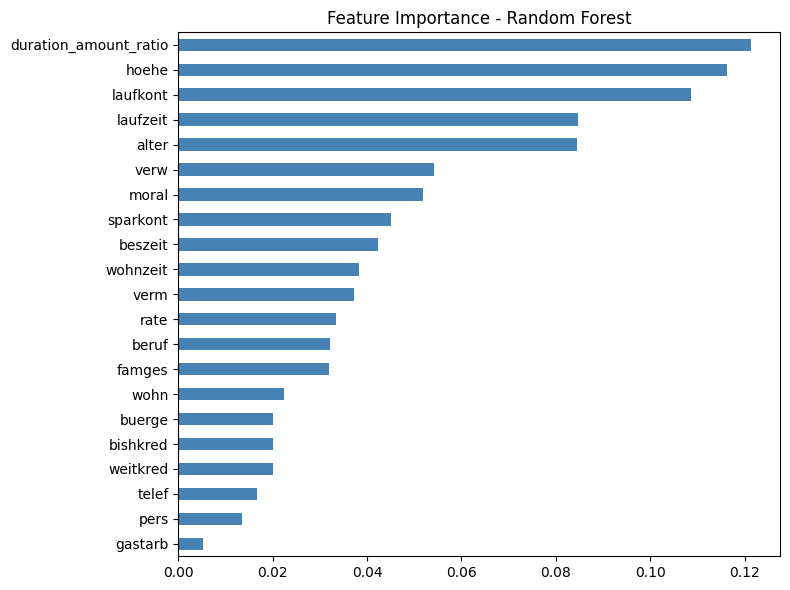

              Model  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.8200  0.8786    0.8483   0.8195
      Decision Tree     0.8151  0.8500    0.8322   0.7595
      Random Forest     0.8153  0.9143    0.8620   0.8296


In [14]:
# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# Comparison table
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        'Model': name,
        'Precision': round(report['1']['precision'], 4),
        'Recall': round(report['1']['recall'], 4),
        'F1-Score': round(report['1']['f1-score'], 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 4)
    })

print(pd.DataFrame(results).to_string(index=False))